# ChEMBL GLP1 Exploratory Data Analysis

Data obtained from ChEMBL filtering for GLP1 target

#### Setup libraries and wide pandas view:

In [146]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/chembl_glp1.csv", sep=';')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

C:\Users\Tom\AppData\Local\Temp\ipykernel_1536\361401215.py:6: DtypeWarning: Columns (0: Assay Subcellular Fraction) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/chembl_glp1.csv", sep=';')


* Pandas raises a DtypeWarning on 'Assay Subcellular Fraction' due to chunked type inference (NaN-only chunks read  as float, but the value-containing chunks as objects). Not a genuine mixed type problem, all the values are strings as found below.

## Do AlogP or Molecular Weight predict GLP-1 potency in this ChEMBL dataset?

### *Part 1 - Structural Audit*

#### Datatypes


In [147]:
print(df.head(5), '\n')
print(df.info(), '\n')

  Molecule ChEMBL ID Molecule Name  Molecule Max Phase  Molecular Weight  #RO5 Violations  AlogP  Compound Key                                             Smiles Standard Type Standard Relation  Standard Value Standard Units  pChEMBL Value Data Validity Comment                Comment    Uo Units  Ligand Efficiency BEI  Ligand Efficiency LE  Ligand Efficiency LLE  Ligand Efficiency SEI  Potential Duplicate Assay ChEMBL ID                                  Assay Description Assay Type BAO Format ID          BAO Label Assay Organism  Assay Tissue ChEMBL ID  Assay Tissue Name Assay Cell Type Assay Subcellular Fraction  Assay Parameters  Assay Variant Accession  Assay Variant Mutation Target ChEMBL ID                       Target Name Target Organism     Target Type Document ChEMBL ID  Source ID     Source Description Document Journal  Document Year Cell ChEMBL ID Properties Action Type Standard Text Value   Value
0      CHEMBL4095693           NaN                 NaN            518.80      

* All datatypes appear to be correct. float64(17), int64(2), str(29)

In [148]:
type_counts = df.apply(lambda col: col.dropna().map(type).nunique())
print('Top five column type counts:', '\n', type_counts.sort_values(ascending=False).head(5), '\n')
print(df['Assay Subcellular Fraction'].dropna().unique(), '\n')

Top five column type counts: 
 Molecule ChEMBL ID    1
Molecule Name         1
Molecule Max Phase    1
Molecular Weight      1
#RO5 Violations       1
dtype: int64 

<StringArray>
['Membrane']
Length: 1, dtype: str 



* No columns have > 1 datatype. Assay Subcellular Fraction contains only the string 'Membrane' and nulls.

#### Missing values and distinct values

In [149]:
print(f"There are {df.isna().sum()[df.isna().sum() > (0.9 * df.shape[0])].count()} columns with >90% missing values, including {df.isna().sum()[df.isna().sum() == df.shape[0]].count()} with all values missing. \nThere are {df.isna().sum()[df.isna().sum() == 0].count()} columns with no missing values.")

summary = pd.DataFrame()
summary['null_values'] = df.isna().sum()
summary['unique_values'] = df.nunique()
print(f"The max unique values in a column is {summary['unique_values'].max()} for {summary['unique_values'].idxmax()}, which is {df['Molecule ChEMBL ID'].count() - summary['unique_values'].max()} short of the full {df['Molecule ChEMBL ID'].count()} rows in the dataset.")

print("Table of missing and unique values for each column:")
print(f"{summary} \n")


There are 22 columns with >90% missing values, including 5 with all values missing. 
There are 16 columns with no missing values.
The max unique values in a column is 107368 for Molecule ChEMBL ID, which is 6518 short of the full 113886 rows in the dataset.
Table of missing and unique values for each column:
                            null_values  unique_values
Molecule ChEMBL ID                    0         107368
Molecule Name                    112271            804
Molecule Max Phase               112630              6
Molecular Weight                     49          19248
#RO5 Violations                    1968              5
AlogP                              1968           1072
Compound Key                          0         107088
Smiles                               52         107346
Standard Type                         0             25
Standard Relation                107696              6
Standard Value                     1223           2657
Standard Units                

* Missing values
    * 48 columns
    * Columns 27, 28, 31-33 have 0 non-null values
    * There are 22 columns with >90% missing values, including 5 with all values missing. 
    * There are 16 columns with no missing values.
    * Standard Relation has 107696 null values. These operators are usually used when a rate/potency is above/below the accurate detection limit. But I do see '=' being used, so it could be different reporting by the different assays.
* Distinct values
    * The max unique values in a column is 107368 in Molecule ChEMBL ID, which is 6518 short of the 113886 rows
        * Some compounds have multiple rows
    * Assay Organism has only 1 unique value but also 1770 nulls. The dataset was labelled as 100% Homo Sapiens on the ChEMBL website, so will assume all are Homo Sapiens.

#### Duplicates

In [150]:
print(f"There are {df.duplicated().sum()} duplicated rows. \n")
mol_count = df['Molecule ChEMBL ID'].value_counts()
mask = df['Molecule ChEMBL ID'].value_counts() > 1

print(f"There are {mol_count[mask].shape[0]} compounds with more than 1 row, and they have up to {mol_count[mask].max()} rows (in the case of {mol_count[mask].idxmax()}). \n")
print(df['Molecule ChEMBL ID'].value_counts().head(5))

selection = df[df['Molecule ChEMBL ID'] == 'CHEMBL4518483']

print(f"\nCHEMBL4518483 has been tested in {selection['Assay ChEMBL ID'].nunique()} unique assays (Assay ChEMBL ID), each with up to {selection.groupby('Assay ChEMBL ID')['Molecule ChEMBL ID'].agg('count').max()} rows/values")

There are 1 duplicated rows. 

There are 3811 compounds with more than 1 row, and they have up to 59 rows (in the case of CHEMBL4518483). 

Molecule ChEMBL ID
CHEMBL4518483    59
CHEMBL410972     55
CHEMBL414357     33
CHEMBL4084119    29
CHEMBL5186808    23
Name: count, dtype: int64

CHEMBL4518483 has been tested in 49 unique assays (Assay ChEMBL ID), each with up to 6 rows/values


* Duplicates
    * Only 1 fully duplicated row 
    * There are 3811 compounds with more than 1 row, and they have up to 59 rows (CHEMBL4518483)
    * CHEMBL4518483 has been tested in 49 unique assays, each with up to 6 values

#### Units and measurement types

How many unique Standard Unit values are there and what are they?

In [151]:
grouped_std_units = df.groupby('Standard Units')['Molecule ChEMBL ID'].agg('count')
print(f"\nThere are {grouped_std_units.count()} different units, but nM covers {100  * grouped_std_units['nM']/grouped_std_units.sum():.1f}% of the entries.\n")

std_units_df = pd.DataFrame()
std_units_df['Count'] = grouped_std_units = df.groupby('Standard Units')['Molecule ChEMBL ID'].agg('count')
std_units_df['Percentage'] = round(df['Standard Units'].value_counts(normalize=True) * 100, 1)
print(std_units_df)


There are 17 different units, but nM covers 97.6% of the entries.

                 Count  Percentage
Standard Units                    
%                 2115         1.9
10'8pM               1         0.0
10^-1/s              1         0.0
10^-2/s             11         0.0
10^-3/s              4         0.0
10^-5M               1         0.0
10^-6M               3         0.0
10^2/Ms              1         0.0
10^3(1/Ms)           3         0.0
10^3/M.s             2         0.0
10^3/M/s             2         0.0
10^4/Ms              7         0.0
10^5/M.s             1         0.0
hr                   1         0.0
nM              110342        97.6
pmol/L               8         0.0
s-1                552         0.5


* **Key finding**: Standard units contains a mixture of rates, concentrations and percentages. This will need to be filtered/separated
* There are 17 different units, but nM covers 97.6% of the entries so could reasonably filter to nM only.

What are the 25 unique values for Standard Type?

In [152]:
print(df['Standard Type'].value_counts())

Standard Type
Potency                  107577
EC50                       2365
%Inhib (Mean)              1032
%Max (Mean)                 558
kon                         552
k_off                       552
IC50                        350
Emax                        300
Activity                    274
Ki                           63
Ratio IC50                   55
Ratio EC50                   53
FC                           49
Kd                           20
Inhibition                   19
Efficacy                     19
Ka                           16
Emin                         10
Kdiss                         9
Ratio                         5
Ke                            4
T1/2                          1
Mean fold stimulation         1
RLU                           1
pEC50                         1
Name: count, dtype: int64


* Standard Type contains 25 unique values. 'Potency' is most common (107577), followed by EC50 (2365). But there are also, %Inhib, %Max, various ratios and rates (kon, koff) etc
* Data will be filtered to Potency as it is by far the most common and will give comparable values.

Filtering to only 'Potency' type measurements and dropping empty columns:

In [153]:
print(f"Dataset shape: {df.shape}")

potency_only = df[df['Standard Type'] == 'Potency']
print(f"Filtering Standard Type to Potency type only. New shape: {potency_only.shape}")
potency_only_dropped_empty = potency_only.dropna(axis=1, how='all') # Drop null columns
print(f"Dropping {potency_only.isna().all().sum()} empty columns. New shape: {potency_only_dropped_empty.shape}")


Dataset shape: (113886, 48)
Filtering Standard Type to Potency type only. New shape: (107577, 48)
Dropping 20 empty columns. New shape: (107577, 28)


* Filtering to Standard Type = Potency and dropping empty columns gives new shape (107577, 28)

Which assays are contained in the data?

In [154]:
print(potency_only_dropped_empty['Assay Description'].value_counts(), '\n')
print(potency_only_dropped_empty['Assay ChEMBL ID'].value_counts(), '\n')

struc_audit_out = potency_only_dropped_empty[potency_only_dropped_empty['Assay ChEMBL ID'] == 'CHEMBL2114788']

print(f"Filtering to {potency_only_dropped_empty['Assay ChEMBL ID'].value_counts().idxmax()} gives shape: {struc_audit_out.shape}")

Assay Description
PubChem BioAssay. qHTS of GLP-1 Receptor Inverse Agonists (Inhibition Mode). (Class of assay: confirmatory)     103901
PubChem BioAssay. qHTS of GLP-1 Receptor Agonists. (Class of assay: confirmatory)                                 3541
PubChem BioAssay. qHTS of GLP-1 Receptor Agonists: Hit Validation.   (Class of assay: confirmatory)                135
Name: count, dtype: int64 

Assay ChEMBL ID
CHEMBL2114788    103901
CHEMBL2114931      3541
CHEMBL3215152       135
Name: count, dtype: int64 

Filtering to CHEMBL2114788 gives shape: (103901, 28)


* Assay Description shows three different assays. Large set of inverse agonists (103901), but also two sets of agonists (3541 & 141). Given the opposite pharmacology.
* Data was filtered to the inverse agonists only (Assay ChEMBL ID = CHEMBL2114788). New shape (103901, 28).

### *Part 2 - Univariate*

#### Shape of Distribution of Standard Value

Analyse the distribution of Standard Value:

Analysis of distribution of Standard Value (potency):
Mean: 14167
Median: 11220
Skew: 0.54
Excess Kutosis: -1.00


<Axes: xlabel='Standard Value', ylabel='Count'>

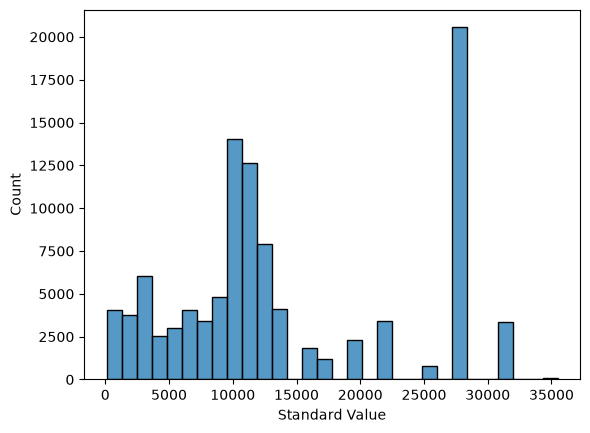

In [155]:
std_value_mean = struc_audit_out['Standard Value'].describe().loc['mean']
std_value_median = struc_audit_out['Standard Value'].describe().loc['50%']
std_value_skew = struc_audit_out['Standard Value'].skew()
std_value_kurt = struc_audit_out['Standard Value'].kurt()
print(f"Analysis of distribution of Standard Value (potency):\nMean: {std_value_mean:.0f}\nMedian: {std_value_median:.0f}\nSkew: {std_value_skew:.2f}\nExcess Kutosis: {std_value_kurt:.2f}")
sns.histplot(struc_audit_out['Standard Value'], bins=30)


* Shape of Distribution of Standard Value
    * Mean = 14167, median = 11220.
    * Skew = 0.54, meaning the tail extends to the right.
    * Excess kurtosis = -0.999, meaning the distribution is platykurtic — flatter than a normal distribution (0).
    * Plotting a histogram shows a distribution centred at 10000 nM with a longer right tail. But with a second peak due to a single highly populated bin at ca. 27000 nM. This may be an artifact, if that was determined to be the lower detection limit in many of the assays.

Investigating the outlier bin in Standard Value histogram:

In [156]:
mask = (struc_audit_out['Standard Value'] > 27000) & (struc_audit_out['Standard Value'] < 29000)
outliers = struc_audit_out[mask]
print(outliers['Standard Value'].value_counts(),'\n')
print('Unique counts:\n', outliers.nunique(), '\n')
print(outliers['Comment'].value_counts())

Standard Value
28183.8    20546
Name: count, dtype: int64 

Unique counts:
 Molecule ChEMBL ID     20517
Molecule Name             82
Molecule Max Phase         5
Molecular Weight        8711
#RO5 Violations            4
AlogP                    753
Compound Key           20545
Smiles                 20510
Standard Type              1
Standard Value             1
Standard Units             1
Comment                    2
Uo Units                   1
Potential Duplicate        1
Assay ChEMBL ID            1
Assay Description          1
Assay Type                 1
BAO Format ID              1
BAO Label                  1
Assay Organism             1
Target ChEMBL ID           1
Target Name                1
Target Organism            1
Target Type                1
Document ChEMBL ID         1
Source ID                  1
Source Description         1
Value                      1
dtype: int64 

Comment
inconclusive    17813
inactive         2733
Name: count, dtype: int64


* Investigating the outlier peak bin [ca. 27,000 nM]: 20,546 rows share the exact value 28183.8 nM.
    * A single repeated value across 20,546 otherwise-independent compounds is not plausible as a genuine measurement - real potency values vary continuously.
    * Confirmed: all 20,546 rows have Comment = 'inconclusive' or 'inactive'.
    * Confirmed: 28183.8 sits exactly on the same half-log dilution series as the rest of the dataset (10000 × 10^0.45) - consistent with it being the maximum tested concentration reported when no activity was observed, rather than a true potency value.
    * **Decision:** exclude these rows from further potency analysis, as the value represents an assay ceiling artifact rather than a real measurement.

Excluded 28183.8 nM values and re-running distribution analysis:

Analysis of distribution of Standard Value (potency):
Mean: 10713
Median: 10000
Skew: 1.18
Excess Kutosis: 1.87
                count  proportion
Standard Value                   
10000.0         14026    0.168268
11220.2         12663    0.151917
12589.3          7918    0.094991
8912.5           4841    0.058077
14125.4          4086    0.049019


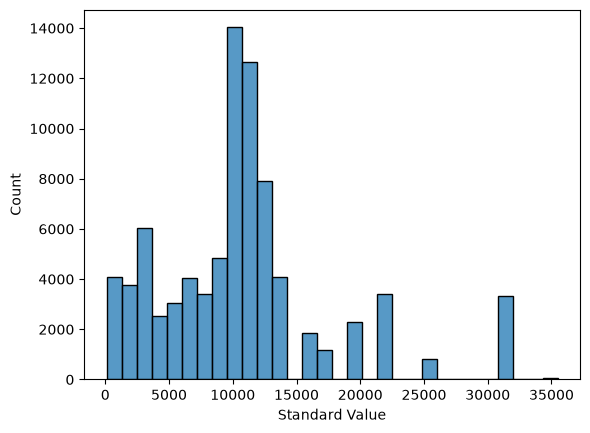

In [157]:
placeholder_excl = struc_audit_out[struc_audit_out['Standard Value'] != 28183.8]
std_value_mean = placeholder_excl['Standard Value'].describe().loc['mean']
std_value_median = placeholder_excl['Standard Value'].describe().loc['50%']
std_value_skew = placeholder_excl['Standard Value'].skew()
std_value_kurt = placeholder_excl['Standard Value'].kurt()
print(f"Analysis of distribution of Standard Value (potency):\nMean: {std_value_mean:.0f}\nMedian: {std_value_median:.0f}\nSkew: {std_value_skew:.2f}\nExcess Kutosis: {std_value_kurt:.2f}")
sns.histplot(placeholder_excl['Standard Value'], bins=30)
std_val_count = pd.concat([placeholder_excl['Standard Value'].value_counts(),
placeholder_excl['Standard Value'].value_counts(normalize=True)], axis=1)
print(std_val_count.head(5))


* Re-analysis After Excluding Standard Value = 28183.8 nM
    * Standard Value mean = 10895.81, median = 10000.00. Standard Value skew = 1.23, excess kurtosis = 1.94.
    * Top Standard Value counts (10000.0, 11220.2, 12589.3, 8912.5, etc) form a geometric series (ratio ≈ 1.122 ≈ 10^0.05) — consistent with standard half-log dilution assay design. Therefore the 10000 median is a result of assay design rather than an artifact.

#### Comments

Compounds with inactive/inconclusive comments:

In [158]:
print(pd.concat([placeholder_excl['Comment'].value_counts(dropna=False), 
                 placeholder_excl['Comment'].value_counts(dropna=False, normalize=True)], axis=1), '\n')

print(f"Filtering to top10 inconclusive results:")
inc_filtered = placeholder_excl[placeholder_excl['Comment'] == 'inconclusive']
print(pd.concat([inc_filtered['Standard Value'].value_counts(),
inc_filtered['Standard Value'].value_counts(normalize=True)], axis=1).head(10), '\n')

print(f"Comparison of top10 all-comment set and inconclusive:")
print(pd.concat([placeholder_excl['Standard Value'].value_counts(normalize=True),
inc_filtered['Standard Value'].value_counts(normalize=True)], axis=1, keys=['all-comments', 'inconclusive']).head(10))


              count  proportion
Comment                        
inconclusive  61943    0.743123
inactive      14980    0.179713
active         6432    0.077164 

Filtering to top10 inconclusive results:
                count  proportion
Standard Value                   
10000.0         10332    0.166799
11220.2          9815    0.158452
12589.3          6404    0.103385
8912.5           3671    0.059264
14125.4          3337    0.053872
31622.8          3061    0.049416
22387.2          2776    0.044815
7943.3           2544    0.041070
19952.6          1921    0.031012
7079.5           1608    0.025959 

Comparison of top10 all-comment set and inconclusive:
                all-comments  inconclusive
Standard Value                            
10000.0             0.168268      0.166799
11220.2             0.151917      0.158452
12589.3             0.094991      0.103385
8912.5              0.058077      0.059264
14125.4             0.049019      0.053872
7943.3              0.041017    

* Comments
    * Within the filtered dataset: 61943 (74%) inconclusive, 14980 (18%) inactive, 6432 (7%) active.
    * Looking at just those results labelled as inconclusive, the distribution of Standard Value is very similar to the wider dataset. Inconclusive rows are not concentration-dependent, ruling out any ceiling/floor artifact explanation.
    * **Decision:** excluding "inconclusive" is a scope choice (to measure resolved potency values only), rather than a data-quality correction. 'Inconclusive' rows will be filtered out and 'inactive' rows will be retained, as they represent a conclusive result.
        * New Standard Value mean = 8845.67, median = 10000.00. Standard Value skew = 1.09, excess kurtosis = 2.16.

#### Interquartile Range Outlier Analysis

IQR Outlier analysis on conclusive results:

In [159]:

conclusive_rows = placeholder_excl[placeholder_excl['Comment'] != 'inconclusive']
print(f"Conclusive rows after filtering: {conclusive_rows.shape[0]} \n")
print(f"Standard Value mean = {conclusive_rows['Standard Value'].mean():.2f} and median = {conclusive_rows['Standard Value'].median():.2f} \n")
print(f"Standard Value skew = {conclusive_rows['Standard Value'].skew():.2f} and excess kurtosis = {conclusive_rows['Standard Value'].kurt():.2f} \n")

q1 = conclusive_rows['Standard Value'].describe()['25%']
q3 = conclusive_rows['Standard Value'].describe()['75%']
iqr = q3 - q1

print(f"For conclusive results, Q1: {q1}, Q3: {q3} and interquartile range: {iqr}")

upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

print(f"Lower fence: {lower_fence:.1f}, Upper fence: {upper_fence:.1f}")

rows_under = conclusive_rows[conclusive_rows['Standard Value'] < lower_fence].shape[0]
rows_over = conclusive_rows[conclusive_rows['Standard Value'] > upper_fence].shape[0]

print(f"There are {rows_under} rows below the lower fence, and {rows_over} above the upper fence")


Conclusive rows after filtering: 21412 

Standard Value mean = 8845.67 and median = 10000.00 

Standard Value skew = 1.09 and excess kurtosis = 2.16 

For conclusive results, Q1: 3981.1, Q3: 11220.2 and interquartile range: 7239.1
Lower fence: -6877.6, Upper fence: 22078.9
There are 0 rows below the lower fence, and 1037 above the upper fence


* Investigating outliers

IQR Outliers:
Standard Value
22387.2    624
31622.8    274
25118.9    135
35481.3      4
Name: count, dtype: int64


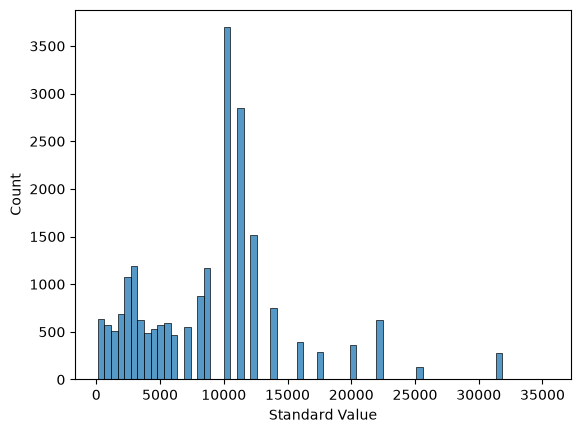

In [160]:
print(f"IQR Outliers:")
sns.histplot(conclusive_rows['Standard Value'])
outliers = conclusive_rows[conclusive_rows['Standard Value'] > upper_fence]
print(outliers['Standard Value'].value_counts())


* IQR Outlier Analysis
    * *(Conclusive rows: excluding 'inconclusive' and value = 28183.8 nM, n = 22326)*
    * Q1: 3981.1, Q3: 11220.2, interquartile range: 7239.1.
    * Lower fence: -6877.6, upper fence: 22078.9.
    * There are 0 rows below the lower fence, and 1037 above the upper fence (ca. 5%).
    * Outliers above the top fence resolve into four values (22387.2, 25118.9, 31622.8, 35481.3), consistent with the same half-log dilution series (from 10000 baseline). Not anomalous data — just the highest tested concentrations. IQR correctly flags them as statistically extreme relative to the bulk of the distribution, but they represent valid, real measurements rather than errors.
    * **Conclusion:** no further row exclusions warranted from the IQR pass.


Box plot of Standard Value:

<Axes: xlabel='Standard Value'>

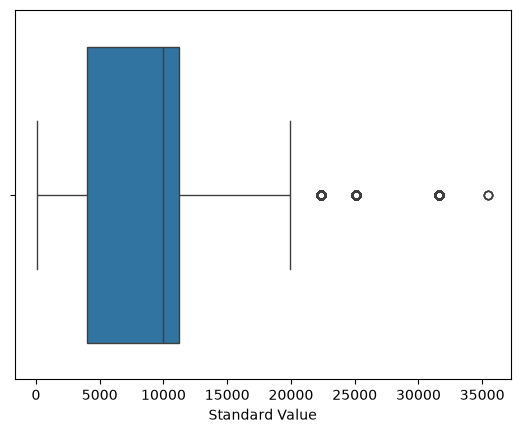

In [161]:
sns.boxplot(x=conclusive_rows['Standard Value'])

* Box Plot
    * Box plot visually confirms IQR analysis — outlier points beyond the upper whisker match the four dilution-series values identified above.

### *Step 3 - Bivariate analysis*

#### Correlation matrices and correlation heatmaps

Pearson
                     Molecule Max Phase  Molecular Weight  #RO5 Violations     AlogP  Standard Value  Potential Duplicate  Source ID     Value
Molecule Max Phase             1.000000          0.097125         0.007819 -0.008343        0.151234                  NaN        NaN  0.151234
Molecular Weight               0.097125          1.000000         0.494750  0.410730       -0.040166                  NaN        NaN -0.040166
#RO5 Violations                0.007819          0.494750         1.000000  0.492518       -0.042123                  NaN        NaN -0.042123
AlogP                         -0.008343          0.410730         0.492518  1.000000       -0.115872                  NaN        NaN -0.115872
Standard Value                 0.151234         -0.040166        -0.042123 -0.115872        1.000000                  NaN        NaN  1.000000
Potential Duplicate                 NaN               NaN              NaN       NaN             NaN                  NaN        NaN  

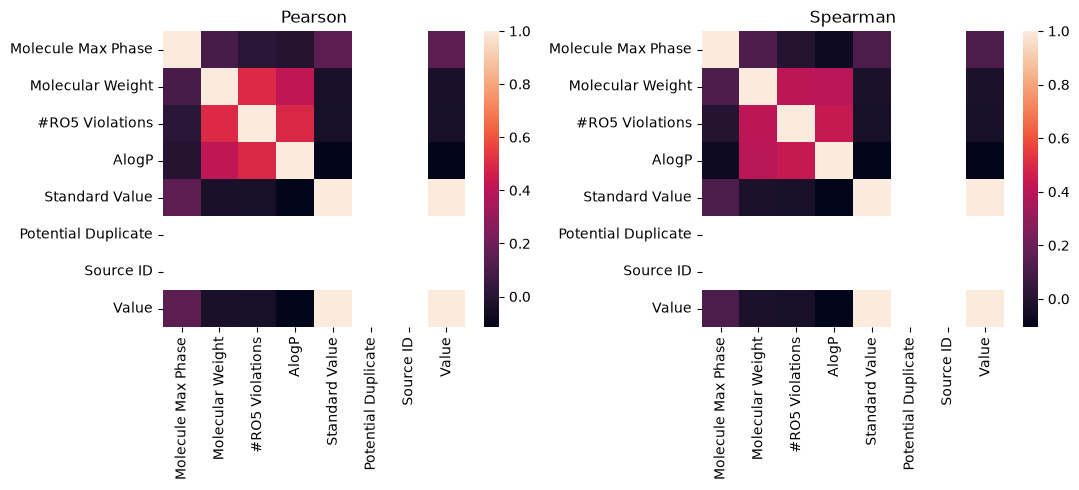

In [162]:
corr_matrix = conclusive_rows.corr(numeric_only=True, method='pearson')
corr_matrix_spear = conclusive_rows.corr(numeric_only=True, method='spearman')
print(f"Pearson")
print(corr_matrix, '\n')
print(f"Spearman")
print(corr_matrix_spear, '\n')

fig, axes = plt.subplots(1, 2, figsize=(11,5))
sns.heatmap(corr_matrix, ax=axes[0])
axes[0].set_title("Pearson")
sns.heatmap(corr_matrix_spear, ax=axes[1])
axes[1].set_title("Spearman")
plt.tight_layout()
plt.show()


* Computed correlation matrices between all numerical columns (Pearson and Spearman) and generated heatmaps
    * Pearson and Spearman agree closely, with the largest shift in ALogP vs Molecule Max Phase and ALogP vs #RO5 violations (both ca. 0.05). This indicates the relationships are well described by either method and are not driven by nonlinear effects.
    * 'Standard value' and 'Value' show a perfect correlation. It appears that value is just a version scaled to uM. Scatter plot is linear.
    * 'Standard value' and 'Molecule Max Phase' show a weak correlation (Pearson = 0.16). 'Molecule Max Phase' contains only 80 non-null values, which makes sense as most compounds do not reach clinical trials.
    * Stronger correlations between '#RO5 Violations' and 'AlogP' (Pearson = 0.49) or 'Molecular Weight' (Pearson = 0.50). This is logical as logP and Molecular weight form part of the rule-of-5 (RO5)

Heatmap of difference between Pearson and Spearman coefficients

Text(0.5, 1.0, 'Difference between Pearson and Spearman')

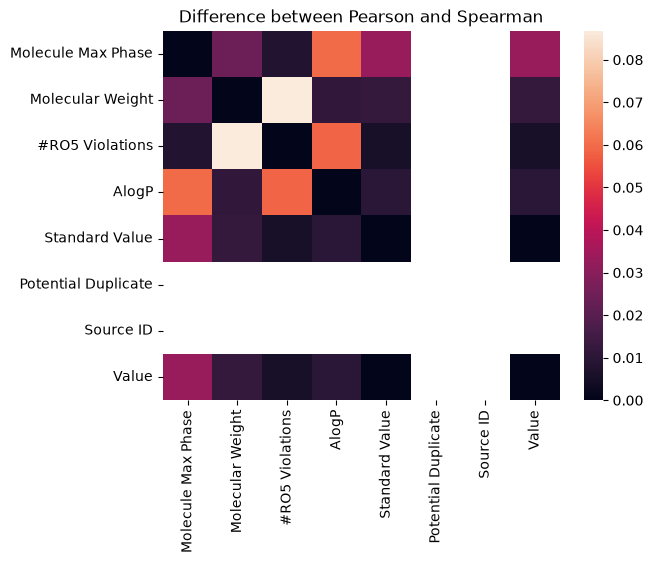

In [163]:
corr_diff = abs(corr_matrix - corr_matrix_spear)
sns.heatmap(corr_diff).set_title('Difference between Pearson and Spearman')

Plots of most correlated fields:

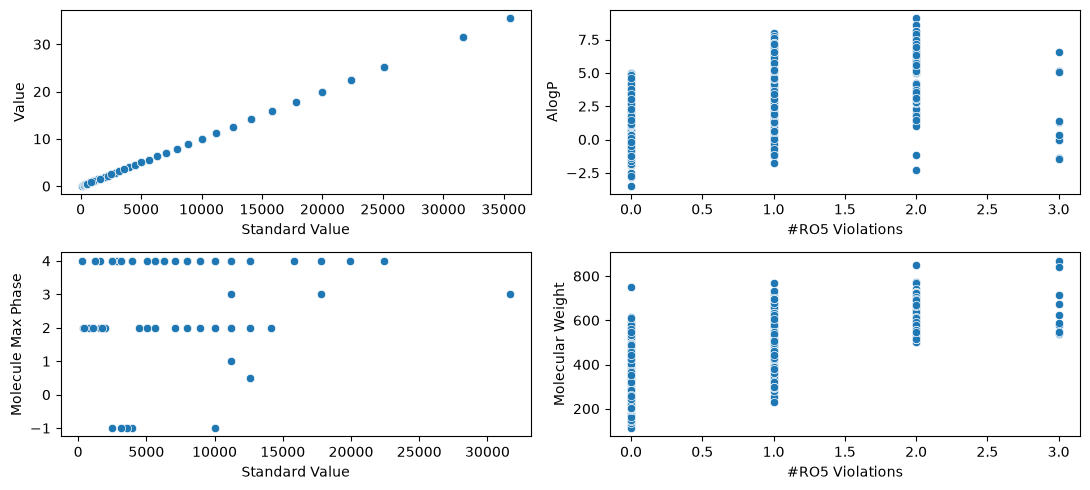

In [164]:
fig, axes = plt.subplots(2, 2, figsize=(11,5))
sns.scatterplot(x=conclusive_rows['Standard Value'], y=conclusive_rows['Value'], ax=axes[0,0])
sns.scatterplot(x=conclusive_rows['Standard Value'], y=conclusive_rows['Molecule Max Phase'], ax=axes[1,0])
sns.scatterplot(x=conclusive_rows['#RO5 Violations'], y=conclusive_rows['AlogP'], ax=axes[0,1])
sns.scatterplot(x=conclusive_rows['#RO5 Violations'], y=conclusive_rows['Molecular Weight'], ax=axes[1,1])
plt.tight_layout()

#### Violin plot of Standard Value vs Comment:

<Axes: xlabel='Comment', ylabel='Standard Value'>

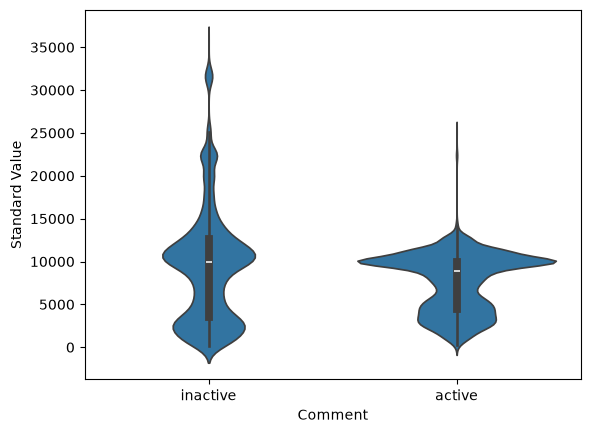

In [165]:
sns.violinplot(y=conclusive_rows['Standard Value'], x=conclusive_rows['Comment'])

* Violin plot of 'Standard Value' vs 'Comment' shows a peak of active compounds at 10000, and a longer tail of inactive compounds extending to 35000+ (very slim beyond 15000 for active)

#### Violin plot of Standard Value vs #ROS violations:

#RO5 Violations
0.0    18886
1.0     2138
2.0      360
3.0       11
Name: count, dtype: int64


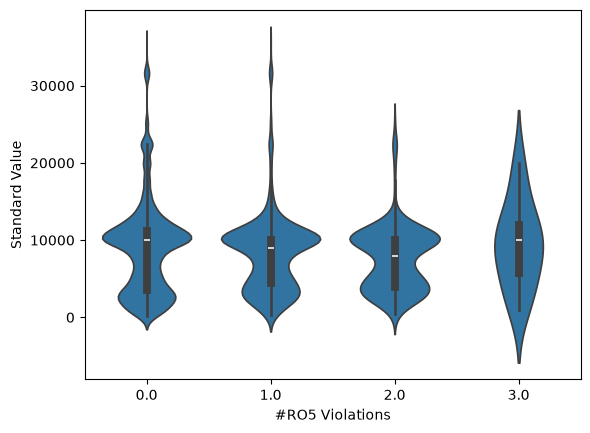

In [166]:
sns.violinplot(y=conclusive_rows['Standard Value'], x=conclusive_rows['#RO5 Violations'])

print(conclusive_rows['#RO5 Violations'].value_counts())

* Violin plot of 'Standard Value' vs '#RO5 Violations' don't show any clear differences. Distribution of compounds with 0, 1 or 2 shows two peaks and long tails. With 3 violations the distribution is much flatter and wider.
    * A value_count shows that the group with 3 violations only contains 11 rows, therefore the change in distribution is likely a result of the small sample.

### *Step 4 - Multivariate analysis*

#### Initial Pairgrid analysis

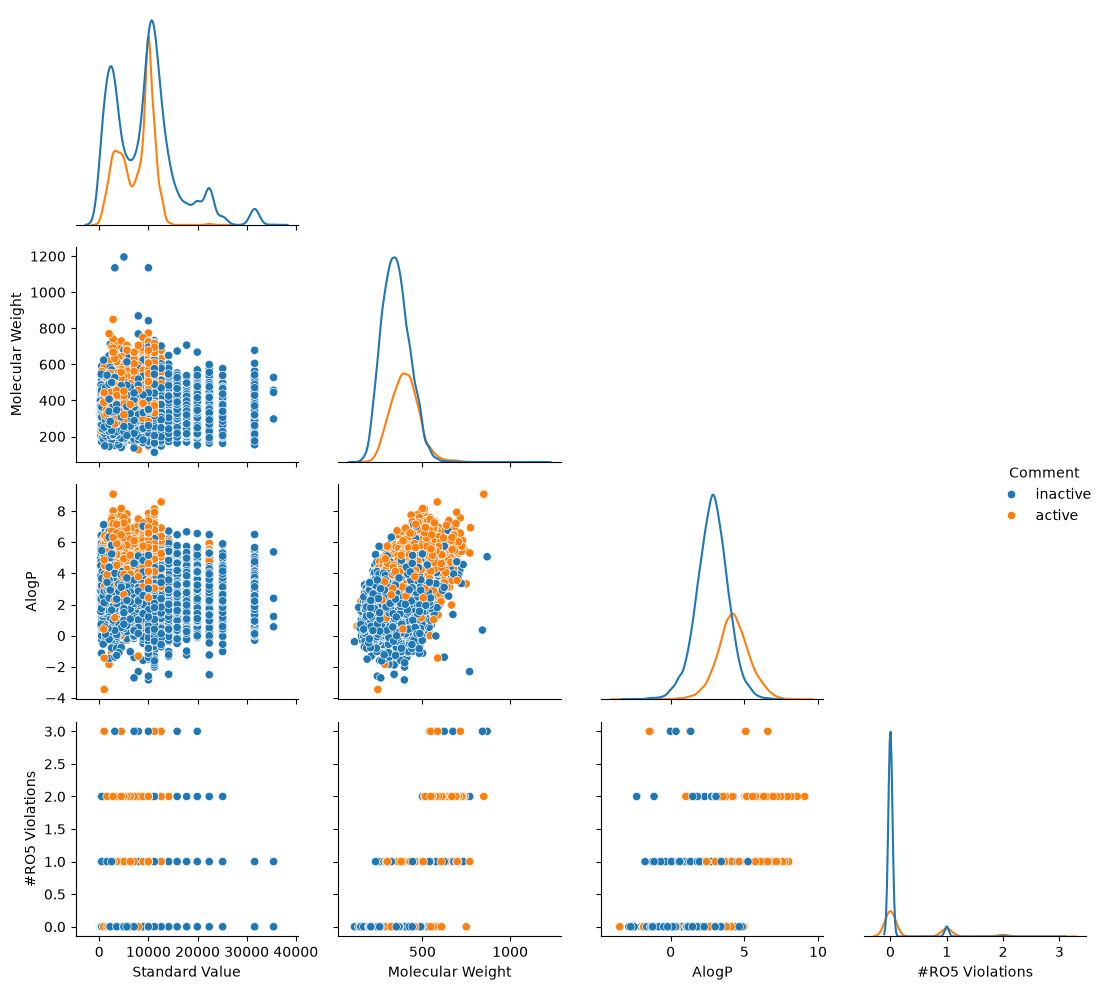

In [167]:
g = sns.PairGrid(conclusive_rows, vars=['Standard Value', 'Molecular Weight', 'AlogP', '#RO5 Violations'], diag_sharey=False, corner=True, hue='Comment')
g.map_offdiag(sns.scatterplot)
g.map_diag(sns.kdeplot)
g.add_legend()
plt.tight_layout()
plt.show()

* Initial Pairgrid analysis does not show any clear relationships between Standard Value and Molecular Weight, AlogP or #RO5 Violations. #RO5 has a relationship with the other descriptors, as they are used in its calculation.

#### Scatterplots of Standard Value vs AlogP or Molecular Weight

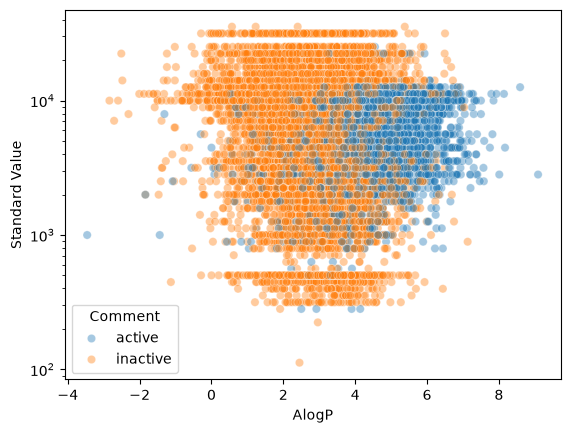

In [168]:
sns.scatterplot(conclusive_rows, x='AlogP', y='Standard Value', hue='Comment', alpha=0.4, hue_order=['active', 'inactive'])
plt.yscale('log')

* Scatterplot of Standard Value vs AlogP coloured by Comment
    * No relationship between Standard Value and AlogP, a broad cloud 
    * Comment hue shows majority of active compounds are clustered between AlogP = 3 and 7, where inactive compounds span 0 to 5

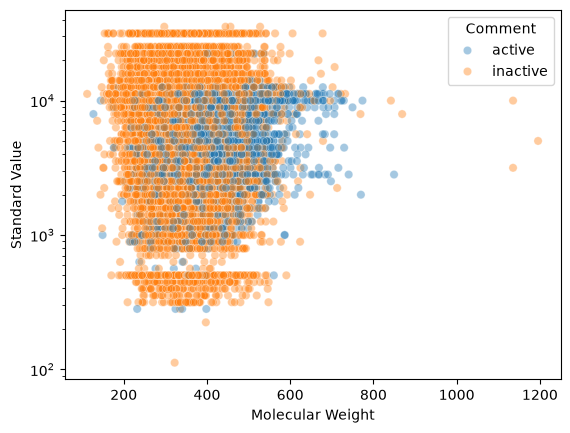

In [169]:
sns.scatterplot(conclusive_rows, x='Molecular Weight', y='Standard Value', hue='Comment', alpha=0.4, hue_order=['active', 'inactive'])
plt.yscale('log')

* Scatterplot of Standard Value vs Molecular Weight coloured by Comment
    * No relationship between Standard Value and Molecular weight
    * Comment Hue shows a weak bias of active compounds to higher molecular weight (400 - 650) vs inactive (200 -500)



**Conclusion**: Activity appears to be markedly more likely at AlogP > ca. 2 and there is a slight preference for higher molecular weight compounds. But generally the SAR appears to be flat when judged by these simple molecular descriptors. It is likely that specific structural changes are driving Standard Value (potency), which are not captured in the dataset as it is.

### *Part 4 - Integrity diagnostics*

#### Zero-variance / constant column audit

In [170]:
print(f"There are {(conclusive_rows.nunique() == 1).sum()} columns containing a single unique value:")

constant_cols = conclusive_rows.columns[conclusive_rows.nunique() == 1]

for idx, val in conclusive_rows[constant_cols].iloc[0].items():
    print(f"{idx} = {val}")

df_modelling_ready = conclusive_rows.drop(columns=constant_cols)
print(f"\nShape of df_modelling_ready:{df_modelling_ready.shape}\n")

print('Null row check:\n', conclusive_rows[constant_cols].isnull().sum()) # Checking for nulls

There are 17 columns containing a single unique value:
Standard Type = Potency
Standard Units = nM
Uo Units = UO_0000065
Potential Duplicate = 0
Assay ChEMBL ID = CHEMBL2114788
Assay Description = PubChem BioAssay. qHTS of GLP-1 Receptor Inverse Agonists (Inhibition Mode). (Class of assay: confirmatory) 
Assay Type = F
BAO Format ID = BAO_0000019
BAO Label = assay format
Assay Organism = Homo sapiens
Target ChEMBL ID = CHEMBL1784
Target Name = Glucagon-like peptide 1 receptor
Target Organism = Homo sapiens
Target Type = SINGLE PROTEIN
Document ChEMBL ID = CHEMBL1201862
Source ID = 7
Source Description = PubChem BioAssays

Shape of df_modelling_ready:(21412, 11)

Null row check:
 Standard Type          0
Standard Units         0
Uo Units               0
Potential Duplicate    0
Assay ChEMBL ID        0
Assay Description      0
Assay Type             0
BAO Format ID          0
BAO Label              0
Assay Organism         0
Target ChEMBL ID       0
Target Name            0
Target Organ

* There are 17 columns containing a single unique value (no nulls in these columns):
    - Standard Type = Potency
    - Standard Units = nM
    - Uo Units = UO_0000065
    - Potential Duplicate = 0
    - Assay ChEMBL ID = CHEMBL2114788
    - Assay Description = PubChem BioAssay. qHTS of GLP-1 Receptor Inverse Agonists (Inhibition Mode). (Class of assay: confirmatory) 
    - Assay Type = F
    - BAO Format ID = BAO_0000019
    - BAO Label = assay format
    - Assay Organism = Homo sapiens
    - Target ChEMBL ID = CHEMBL1784
    - Target Name = Glucagon-like peptide 1 receptor
    - Target Organism = Homo sapiens
    - Target Type = SINGLE PROTEIN
    - Document ChEMBL ID = CHEMBL1201862
    - Source ID = 7
    - Source Description = PubChem BioAssays
* Created df_modelling_ready with columns above dropped. Shape: (21412, 11)
    * A one-off demonstration snapshot, main dataframe retains these columns. 

#### Derived/redundant column audit

In [171]:
print(conclusive_rows.head(1))
print(conclusive_rows.info())

    Molecule ChEMBL ID Molecule Name  Molecule Max Phase  Molecular Weight  #RO5 Violations  AlogP Compound Key                             Smiles Standard Type  Standard Value Standard Units   Comment    Uo Units  Potential Duplicate Assay ChEMBL ID                                  Assay Description Assay Type BAO Format ID     BAO Label Assay Organism Target ChEMBL ID                       Target Name Target Organism     Target Type Document ChEMBL ID  Source ID Source Description   Value
129      CHEMBL1537791           NaN                 NaN            321.41              0.0   3.61  SID24813643  CSc1ccc(CNc2nc3ccccc3n3cnnc23)cc1       Potency          5623.4             nM  inactive  UO_0000065                    0   CHEMBL2114788  PubChem BioAssay. qHTS of GLP-1 Receptor Inver...          F   BAO_0000019  assay format   Homo sapiens       CHEMBL1784  Glucagon-like peptide 1 receptor    Homo sapiens  SINGLE PROTEIN      CHEMBL1201862          7  PubChem BioAssays  5.6234
<class '

* The lipinski rule of 5 that is used to determine '#RO5 Violations' is:  
    * Molecular Weight < 500
    * LogP <= 5
    * Hydrogen Bond Donors <= 5
    * Hydrogen Bond Acceptors: <= 10
    Meaning that #RO5 Violations is derived from Molecular Weight and (a version of) AlogP
* Standard Value and Value are the same potency values scaled to different units (nM vs µM)

#### Sparse columns

* Molecule Name (141 non-null, 0.7%) and Molecule Max Phase (74 non-null, 0.35%) have a very small fraction non-null

#### Schema verification checks

In [172]:
expected_cols = ['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Value', 'Standard Units', 'Comment', 'Uo Units', 'Potential Duplicate', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism', 'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID', 'Source Description', 'Value']

def check_columns(df, expected_cols):
    missing = set(expected_cols) - set(df.columns)
    extra = set(df.columns) - set(expected_cols)
    if not missing and not extra:
        print("Columns match expected schema")
    else:
        if missing:
            print(f"Missing columns: {missing}")
        if extra:
            print(f"Unexpected columns: {extra}")

def check_single_assay(df, col='Assay ChEMBL ID'):
    n = df[col].nunique()
    if n == 1:
        print(f"Single {col}: {df[col].iloc[0]}")
    else:
        print(f"Multiple values ({df[col].unique()}) in {col}")

def check_no_placeholder_value(df, col='Standard Value', placeholder=28183.8):
    n = (df[col] == placeholder).sum()
    if n == 0:
        print(f"No {col} rows at placeholder: {placeholder}")
    else:
        print(f"{n} rows in {col} at placeholder value {placeholder}")

def check_value_range(df, col='Standard Value', min_val=0):
    n = (df[col] <= min_val).sum()
    if n == 0:
        print(f"All {col} values > {min_val}")
    else:
        print(f"{n} rows found with {col} values <= {min_val}")

def check_allowed_categories(df, col, allowed):
    unexpected = set(df[col].dropna().unique()) - set(allowed)
    if not unexpected:
        print(f"{col} contains only allowed categories")
    else:
        print(f"Unexpected values in {col}: {unexpected}")

print(f"Running schema checks:")
check_columns(conclusive_rows, expected_cols)
check_single_assay(conclusive_rows)
check_value_range(conclusive_rows)
check_no_placeholder_value(conclusive_rows)
check_allowed_categories(conclusive_rows, 'Comment', ['active', 'inactive'])

Running schema checks:
Columns match expected schema
Single Assay ChEMBL ID: CHEMBL2114788
All Standard Value values > 0
No Standard Value rows at placeholder: 28183.8
Comment contains only allowed categories


* Wrote functions to check:
    * check_columns to compare column list against expected
    * check_single_assay to check there is only one unique value in Assay ChEMBL ID
    * check_no_placeholder_value to confirm that the 28183.8nM placeholder in Standard Value has been filtered out
    * check_value_range to confirm there are no Standard Value values below zero
    * check_allowed_categories to check categories in Comment against an allowed list